In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

project_path = "/content/drive/MyDrive/ML_Safety_Project"

os.chdir(project_path)

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
/content/drive/MyDrive/ML_Safety_Project


In [3]:
!unzip datasets/2026.zip -d datasets/

Archive:  datasets/2026.zip
replace datasets/2026/test-fog.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [12]:
print(os.listdir("datasets/2026"))

['train.zip', 'test.zip', 'test-fog.zip', 'test-night.zip', 'validation.zip', 'test-town-01.zip']


In [13]:
!unzip "datasets/2026/train.zip" -d "datasets/2026/"

Streaming output truncated to the last 5000 lines.
  inflating: datasets/2026/train/segmentation-front/018200.png  
  inflating: datasets/2026/train/segmentation-front/051780.png  
  inflating: datasets/2026/train/segmentation-front/060390.png  
  inflating: datasets/2026/train/segmentation-front/034870.png  
  inflating: datasets/2026/train/segmentation-front/052420.png  
  inflating: datasets/2026/train/segmentation-front/012470.png  
  inflating: datasets/2026/train/segmentation-front/020180.png  
  inflating: datasets/2026/train/segmentation-front/015280.png  
  inflating: datasets/2026/train/segmentation-front/029700.png  
  inflating: datasets/2026/train/segmentation-front/024970.png  
  inflating: datasets/2026/train/segmentation-front/041470.png  
  inflating: datasets/2026/train/segmentation-front/007800.png  
  inflating: datasets/2026/train/segmentation-front/000180.png  
  inflating: datasets/2026/train/segmentation-front/047100.png  
  inflating: datasets/2026/train/segmen

In [15]:
print(os.listdir("datasets/2026/train"))

['rgb-front', 'sim.log', 'imu.feather', 'segmentation-front', 'carla.log', 'labels.csv', '.hydra', 'actions.feather', 'labels.feather', 'gnss.feather', 'weather.feather', 'collisions.feather']


In [16]:
train_path = "datasets/2026/train/rgb-front"

print("Training Images:", len(os.listdir(train_path)))

Training Images: 7200


In [17]:
!unzip "datasets/2026/test.zip" -d "datasets/2026/"

Streaming output truncated to the last 5000 lines.
  inflating: datasets/2026/test/rgb-front/031970.jpg  
  inflating: datasets/2026/test/rgb-front/035240.jpg  
  inflating: datasets/2026/test/rgb-front/029910.jpg  
  inflating: datasets/2026/test/rgb-front/010750.jpg  
  inflating: datasets/2026/test/rgb-front/014200.jpg  
  inflating: datasets/2026/test/rgb-front/026670.jpg  
  inflating: datasets/2026/test/rgb-front/007250.jpg  
  inflating: datasets/2026/test/rgb-front/034390.jpg  
  inflating: datasets/2026/test/rgb-front/027920.jpg  
  inflating: datasets/2026/test/rgb-front/033040.jpg  
  inflating: datasets/2026/test/rgb-front/021990.jpg  
  inflating: datasets/2026/test/rgb-front/031590.jpg  
  inflating: datasets/2026/test/rgb-front/010620.jpg  
  inflating: datasets/2026/test/rgb-front/022240.jpg  
  inflating: datasets/2026/test/rgb-front/032640.jpg  
  inflating: datasets/2026/test/rgb-front/013930.jpg  
  inflating: datasets/2026/test/rgb-front/020680.jpg  
  inflating: d

In [55]:
!unzip "datasets/2026/validation.zip" -d "datasets/2026/"

Streaming output truncated to the last 5000 lines.
  inflating: datasets/2026/validation/rgb-front/022030.jpg  
  inflating: datasets/2026/validation/rgb-front/022040.jpg  
  inflating: datasets/2026/validation/rgb-front/022050.jpg  
  inflating: datasets/2026/validation/rgb-front/022060.jpg  
  inflating: datasets/2026/validation/rgb-front/022070.jpg  
  inflating: datasets/2026/validation/rgb-front/022080.jpg  
  inflating: datasets/2026/validation/rgb-front/022090.jpg  
  inflating: datasets/2026/validation/rgb-front/022100.jpg  
  inflating: datasets/2026/validation/rgb-front/022110.jpg  
  inflating: datasets/2026/validation/rgb-front/022120.jpg  
  inflating: datasets/2026/validation/rgb-front/022130.jpg  
  inflating: datasets/2026/validation/rgb-front/022140.jpg  
  inflating: datasets/2026/validation/rgb-front/022150.jpg  
  inflating: datasets/2026/validation/rgb-front/022160.jpg  
  inflating: datasets/2026/validation/rgb-front/022170.jpg  
  inflating: datasets/2026/validat

In [18]:
test_path = "datasets/2026/test/rgb-front"

print("Test Images:", len(os.listdir(test_path)))

Test Images: 3600


In [19]:
import pandas as pd

In [20]:
labels_df = pd.read_csv("datasets/2026/train/labels.csv")

In [21]:
print(labels_df.head())

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  


In [22]:
print("Traffic Light:", labels_df["has_traffic_light"].sum())
print("Pedestrian:", labels_df["has_pedestrian"].sum())
print("Vehicle:", labels_df["has_vehicle"].sum())

Traffic Light: 5276
Pedestrian: 1718
Vehicle: 5458


In [23]:
import matplotlib.pyplot as plt
from PIL import Image

In [24]:
sample_images = os.listdir(train_path)[:4]

print(sample_images)

['029290.jpg', '050370.jpg', '053320.jpg', '055980.jpg']


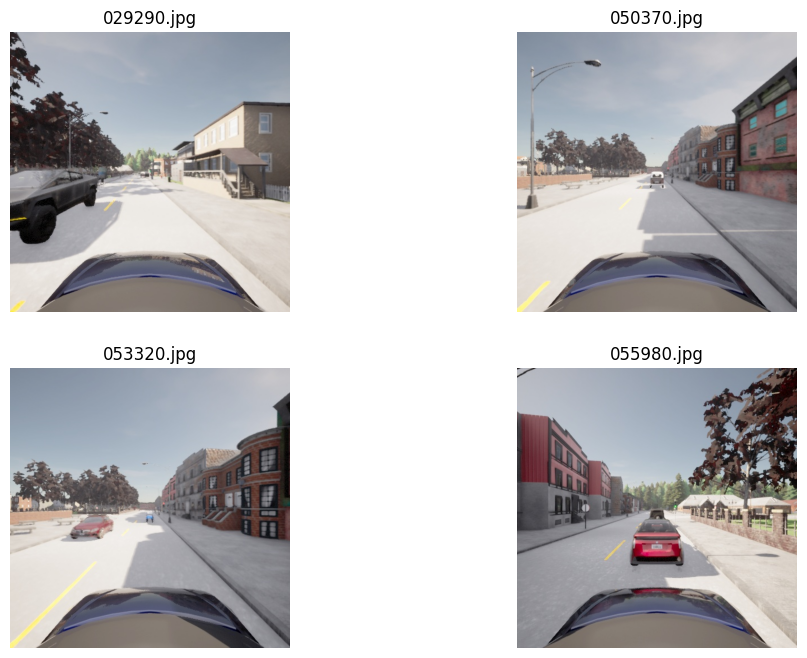

In [25]:
plt.figure(figsize=(12,8))

for i, img_name in enumerate(sample_images):

    img_path = os.path.join(train_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)

    plt.title(img_name)
    plt.axis("off")

plt.show()

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

In [27]:
from torchvision import datasets, transforms, models

In [28]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [29]:
from torch.utils.data import Dataset

In [30]:
class CarlaDataset(Dataset):

    def __init__(self, image_folder, labels_file, label_column, transform=None):

        self.image_folder = image_folder
        self.labels_df = pd.read_csv(labels_file)

        self.label_column = label_column
        self.transform = transform

    def __len__(self):

        return len(self.labels_df)

    def __getitem__(self, idx):

        row = self.labels_df.iloc[idx]

        image_name = f"{int(row['frame']):06d}.jpg"

        image_path = os.path.join(self.image_folder, image_name)

        image = Image.open(image_path).convert("RGB")

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [31]:
pedestrian_dataset = CarlaDataset(
    image_folder="datasets/2026/train/rgb-front",
    labels_file="datasets/2026/train/labels.csv",
    label_column="has_pedestrian",
    transform=transform
)

In [32]:
image, label = pedestrian_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0.0


In [33]:
from torch.utils.data import DataLoader

In [65]:
pedestrian_val_dataset = CarlaDataset(
    image_folder="datasets/2026/validation/rgb-front",
    labels_file="datasets/2026/validation/labels.csv",
    label_column="has_pedestrian",
    transform=transform
)

In [66]:
pedestrian_train_loader = DataLoader(
    pedestrian_dataset,
    batch_size=32,
    shuffle=True
)

pedestrian_val_loader = DataLoader(
    pedestrian_val_dataset,
    batch_size=32,
    shuffle=False
)

In [67]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [68]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [69]:
train_losses = []
val_losses = []

In [70]:
num_epochs = 5

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_train_loss = 0.0

    for images, labels in pedestrian_train_loader:

        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(pedestrian_train_loader)

    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in pedestrian_val_loader:

            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(pedestrian_val_loader)

    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Validation Loss = {avg_val_loss:.4f}")

Epoch 1: Train Loss = 0.5145, Validation Loss = 0.6285
Epoch 2: Train Loss = 0.4150, Validation Loss = 0.5446
Epoch 3: Train Loss = 0.3626, Validation Loss = 0.6386
Epoch 4: Train Loss = 0.3155, Validation Loss = 0.6952
Epoch 5: Train Loss = 0.2809, Validation Loss = 0.6870


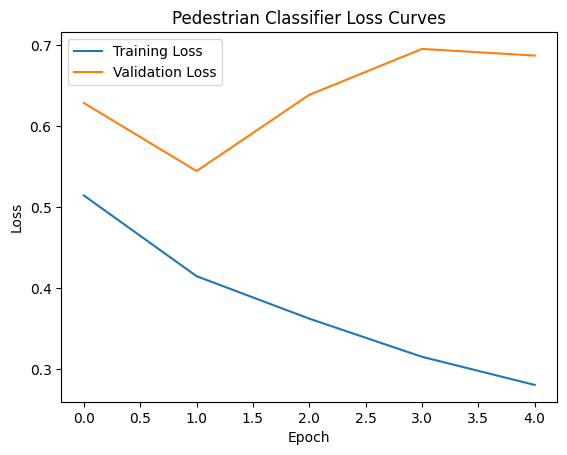

In [71]:
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pedestrian Classifier Loss Curves")

plt.legend()

plt.show()

In [72]:
vehicle_dataset = CarlaDataset(
    image_folder="datasets/2026/train/rgb-front",
    labels_file="datasets/2026/train/labels.csv",
    label_column="has_vehicle",
    transform=transform
)

In [73]:
vehicle_val_dataset = CarlaDataset(
    image_folder="datasets/2026/validation/rgb-front",
    labels_file="datasets/2026/validation/labels.csv",
    label_column="has_vehicle",
    transform=transform
)

In [74]:
vehicle_train_loader = DataLoader(
    vehicle_dataset,
    batch_size=32,
    shuffle=True
)

vehicle_val_loader = DataLoader(
    vehicle_val_dataset,
    batch_size=32,
    shuffle=False
)

In [75]:
vehicle_model = models.resnet18(pretrained=True)

vehicle_model.fc = nn.Linear(vehicle_model.fc.in_features, 1)

vehicle_model = vehicle_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [76]:
vehicle_criterion = nn.BCEWithLogitsLoss()

vehicle_optimizer = optim.Adam(vehicle_model.parameters(), lr=0.001)

In [77]:
vehicle_train_losses = []
vehicle_val_losses = []

In [78]:
num_epochs = 5

for epoch in range(num_epochs):

    # TRAINING
    vehicle_model.train()

    running_train_loss = 0.0

    for images, labels in vehicle_train_loader:

        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        vehicle_optimizer.zero_grad()

        outputs = vehicle_model(images)

        loss = vehicle_criterion(outputs, labels)

        loss.backward()

        vehicle_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(vehicle_train_loader)

    vehicle_train_losses.append(avg_train_loss)

    # VALIDATION
    vehicle_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in vehicle_val_loader:

            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = vehicle_model(images)

            loss = vehicle_criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(vehicle_val_loader)

    vehicle_val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Validation Loss = {avg_val_loss:.4f}")

Epoch 1: Train Loss = 0.3321, Validation Loss = 0.3100
Epoch 2: Train Loss = 0.2308, Validation Loss = 0.2832
Epoch 3: Train Loss = 0.2034, Validation Loss = 0.3490
Epoch 4: Train Loss = 0.1725, Validation Loss = 0.3375
Epoch 5: Train Loss = 0.1663, Validation Loss = 0.3032


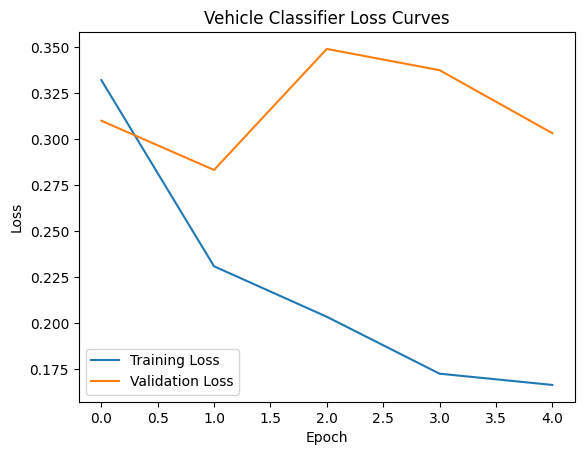

In [79]:
plt.plot(vehicle_train_losses, label="Training Loss")
plt.plot(vehicle_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Vehicle Classifier Loss Curves")

plt.legend()

plt.show()

In [80]:
traffic_dataset = CarlaDataset(
    image_folder="datasets/2026/train/rgb-front",
    labels_file="datasets/2026/train/labels.csv",
    label_column="has_traffic_light",
    transform=transform
)

In [81]:
traffic_val_dataset = CarlaDataset(
    image_folder="datasets/2026/validation/rgb-front",
    labels_file="datasets/2026/validation/labels.csv",
    label_column="has_traffic_light",
    transform=transform
)

In [82]:
traffic_train_loader = DataLoader(
    traffic_dataset,
    batch_size=32,
    shuffle=True
)

traffic_val_loader = DataLoader(
    traffic_val_dataset,
    batch_size=32,
    shuffle=False
)

In [83]:
traffic_model = models.resnet18(pretrained=True)

traffic_model.fc = nn.Linear(traffic_model.fc.in_features, 1)

traffic_model = traffic_model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [84]:
traffic_criterion = nn.BCEWithLogitsLoss()

traffic_optimizer = optim.Adam(traffic_model.parameters(), lr=0.001)

In [85]:
traffic_train_losses = []
traffic_val_losses = []

In [86]:
num_epochs = 5

for epoch in range(num_epochs):

    # TRAINING
    traffic_model.train()

    running_train_loss = 0.0

    for images, labels in traffic_train_loader:

        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        traffic_optimizer.zero_grad()

        outputs = traffic_model(images)

        loss = traffic_criterion(outputs, labels)

        loss.backward()

        traffic_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(traffic_train_loader)

    traffic_train_losses.append(avg_train_loss)

    # VALIDATION
    traffic_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in traffic_val_loader:

            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = traffic_model(images)

            loss = traffic_criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(traffic_val_loader)

    traffic_val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Validation Loss = {avg_val_loss:.4f}")

Epoch 1: Train Loss = 0.1859, Validation Loss = 0.1794
Epoch 2: Train Loss = 0.0871, Validation Loss = 0.1158
Epoch 3: Train Loss = 0.0628, Validation Loss = 0.1136
Epoch 4: Train Loss = 0.0521, Validation Loss = 0.0971
Epoch 5: Train Loss = 0.0504, Validation Loss = 0.0930


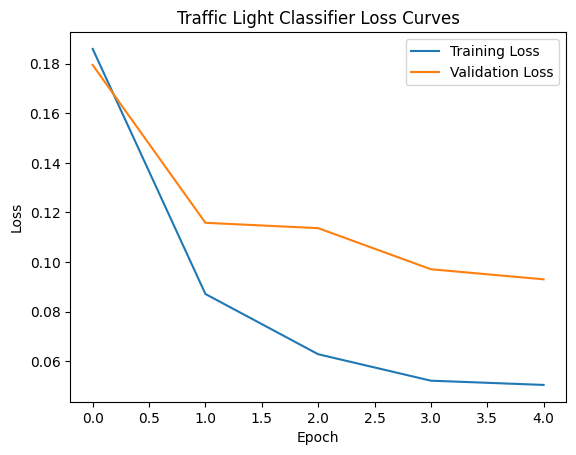

In [87]:
plt.plot(traffic_train_losses, label="Training Loss")
plt.plot(traffic_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Traffic Light Classifier Loss Curves")

plt.legend()

plt.show()

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [89]:
pedestrian_test_dataset = CarlaDataset(
    image_folder="datasets/2026/test/rgb-front",
    labels_file="datasets/2026/test/labels.csv",
    label_column="has_pedestrian",
    transform=transform
)

In [90]:
pedestrian_test_loader = DataLoader(
    pedestrian_test_dataset,
    batch_size=32,
    shuffle=False
)

In [92]:
pedestrian_model = model

In [93]:
pedestrian_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in pedestrian_test_loader:

        images = images.to(device)

        outputs = pedestrian_model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

In [95]:
import numpy as np

In [96]:
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

In [97]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7230555555555556
Precision: 0.37659033078880405
Recall: 0.6288951841359773
F1-score: 0.47108753315649865


In [98]:
vehicle_test_dataset = CarlaDataset(
    image_folder="datasets/2026/test/rgb-front",
    labels_file="datasets/2026/test/labels.csv",
    label_column="has_vehicle",
    transform=transform
)

In [99]:
vehicle_test_loader = DataLoader(
    vehicle_test_dataset,
    batch_size=32,
    shuffle=False
)

In [100]:
vehicle_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in vehicle_test_loader:

        images = images.to(device)

        outputs = vehicle_model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

In [101]:
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

In [102]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8897222222222222
Precision: 0.9324070597070973
Recall: 0.9196296296296296
F1-score: 0.9259742681335074


In [103]:
traffic_test_dataset = CarlaDataset(
    image_folder="datasets/2026/test/rgb-front",
    labels_file="datasets/2026/test/labels.csv",
    label_column="has_traffic_light",
    transform=transform
)

In [104]:
traffic_test_loader = DataLoader(
    traffic_test_dataset,
    batch_size=32,
    shuffle=False
)

In [105]:
traffic_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in traffic_test_loader:

        images = images.to(device)

        outputs = traffic_model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

In [106]:
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

In [107]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9302777777777778
Precision: 0.9509083880943178
Recall: 0.9520123839009288
F1-score: 0.9514600657513054


In [110]:
torch.save(
    pedestrian_model.state_dict(),
    "/content/drive/MyDrive/ML_Safety_Project/models/pedestrian_model.pth"
)

In [111]:
torch.save(
    vehicle_model.state_dict(),
    "/content/drive/MyDrive/ML_Safety_Project/models/vehicle_model.pth"
)

In [112]:
torch.save(
    traffic_model.state_dict(),
    "/content/drive/MyDrive/ML_Safety_Project/models/traffic_model.pth"
)